# InceptionTime - SOTA deep learning for TS

In [1]:
# %%
import os
import sys
import time
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (balanced_accuracy_score, f1_score, classification_report,
                             confusion_matrix, matthews_corrcoef, brier_score_loss,
                             ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

# Call it immediately
set_seed(42)

# --- Project Root Setup ---
def find_project_root(name='Bambino', start=None):
    if start is None: start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name: return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir: return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
if PROJECT_ROOT: sys.path.append(PROJECT_ROOT)

from config import settings
import config_inception as cfg

try:
    from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
except ImportError:
    raise ImportError("Could not import BoaOpenFaceDataset.")

from _utils_ import dataset_utils

# --- Configuration ---
OUT_DIR = Path("./results_InceptionTime")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_LEN = cfg.TARGET_LEN          
BATCH_SIZE = cfg.BATCH_SIZE
NUM_EPOCHS = cfg.NUM_EPOCHS
LR = cfg.LR
WEIGHT_DECAY = cfg.WEIGHT_DECAY
PATIENCE = cfg.PATIENCE              
DEVICE = cfg.DEVICE
PRINT_EVERY = cfg.PRINT_EVERY
MODALITIES = cfg.MODALITIES
numeric_features = cfg.numeric_features
cat_features = cfg.cat_features

# %% --- Data Helpers ---
def ds_to_numpy_and_meta(ds, modalities=MODALITIES, target_len=TARGET_LEN):
    modality_map = {'g': 'gaze_info', 'h': 'head_info', 'f': 'face_info'}
    X_list, metas = [], []
    
    for inst in ds.instances:
        mats = []
        for m in modalities:
            attr = modality_map[m]
            mat = getattr(inst, attr)
            mats.append(np.asarray(mat))
        
        X = np.concatenate(mats, axis=1)
        L = X.shape[0]
        
        if L >= target_len:
            start = (L - target_len) // 2
            X_t = X[start:start+target_len, :]
        else:
            pad = np.zeros((target_len - L, X.shape[1]), dtype=X.dtype)
            X_t = np.vstack([X, pad])
            
        X_list.append(X_t.T)
        
        age = float(inst.age) if inst.age is not None else np.nan
        meta_row = {
            'pt_id': inst.pt_id,
            'trial_id': inst.trial_id,
            'label': int(inst.trial_type),
            'age': age,
            'sex': inst.sex if hasattr(inst, 'sex') else np.nan,
            'duration_s': L / getattr(ds, "FRAME_RATE", 25)
        }
        metas.append(meta_row)
        
    X_arr = np.stack(X_list, axis=0).astype(np.float32)
    meta_df = pd.DataFrame(metas)
    return X_arr, meta_df

# %% --- Load Data ---
print("\n📂 Loading datasets...")
DATASET_TYPE = 'augmented_normalized' 

TRAIN_PATH = settings.get_dataset_path(DATASET_TYPE, settings.training_filename)
VAL_PATH = settings.get_dataset_path(DATASET_TYPE, settings.validation_filename)
TEST_PATH = settings.get_dataset_path(DATASET_TYPE, settings.test_filename)

train_ds = BoaOpenFaceDataset.load_dataset(TRAIN_PATH)
val_ds   = BoaOpenFaceDataset.load_dataset(VAL_PATH)
test_ds  = BoaOpenFaceDataset.load_dataset(TEST_PATH)

print(f"Instances: Train {len(train_ds)}, Val {len(val_ds)}, Test {len(test_ds)}")

# Convert
X_train_ts, df_train_meta = ds_to_numpy_and_meta(train_ds)
X_val_ts,   df_val_meta   = ds_to_numpy_and_meta(val_ds)
X_test_ts,  df_test_meta  = ds_to_numpy_and_meta(test_ds)

y_train = df_train_meta['label'].values
y_val   = df_val_meta['label'].values
y_test  = df_test_meta['label'].values

# Metadata
print("   Processing Metadata...")
meta_preproc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='drop'
)

X_meta_train = meta_preproc.fit_transform(df_train_meta[numeric_features + cat_features])
X_meta_val   = meta_preproc.transform(df_val_meta[numeric_features + cat_features])
X_meta_test  = meta_preproc.transform(df_test_meta[numeric_features + cat_features])

# Save Artifacts
import joblib
joblib.dump(meta_preproc, OUT_DIR/"meta_preproc.joblib")

# %% --- PyTorch Loaders ---
def build_loader(X_ts, X_meta, y, batch_size=BATCH_SIZE, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X_ts, dtype=torch.float32),
        torch.tensor(X_meta, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = build_loader(X_train_ts, X_meta_train, y_train, shuffle=True)
val_loader   = build_loader(X_val_ts, X_meta_val, y_val, shuffle=False)
test_loader  = build_loader(X_test_ts, X_meta_test, y_test, shuffle=False)



📂 Loading datasets...
Instances: Train 1970, Val 140, Test 137
   Processing Metadata...


## Model and Training

In [2]:
# %% --- InceptionTime Architecture (Lite) ---
set_seed(42)

class InceptionModule(nn.Module):
    def __init__(self, in_channels, nb_filters, kernel_size, bottleneck_size, activation=nn.ReLU()):
        super().__init__()
        
        # 1. Bottleneck
        if in_channels > 1 and bottleneck_size is not None:
            self.bottleneck = nn.Conv1d(in_channels, bottleneck_size, 1, bias=False)
            input_channels = bottleneck_size
        else:
            self.bottleneck = nn.Identity()
            input_channels = in_channels
            
        # 2. Parallel Convolutions
        k1 = kernel_size
        k2 = kernel_size // 2 + 1
        k3 = kernel_size // 4 + 1
        
        # Padding = k // 2 works for odd k. For even k, it adds 1 extra pixel.
        self.conv1 = nn.Conv1d(input_channels, nb_filters, k1, padding=k1//2, bias=False)
        self.conv2 = nn.Conv1d(input_channels, nb_filters, k2, padding=k2//2, bias=False)
        self.conv3 = nn.Conv1d(input_channels, nb_filters, k3, padding=k3//2, bias=False)
        
        # 3. Max Pooling
        self.maxpool = nn.MaxPool1d(3, stride=1, padding=1)
        self.conv_pool = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        
        self.bn = nn.BatchNorm1d(nb_filters * 4)
        self.act = activation

    def forward(self, x):
        x_in = x
        x_bottle = self.bottleneck(x)
        
        # Get target length from input
        target_len = x.shape[-1]
        
        # Slicing [..., :target_len] ensures we chop off the extra pixel 
        # if a kernel was even sized.
        out1 = self.conv1(x_bottle)[..., :target_len]
        out2 = self.conv2(x_bottle)[..., :target_len]
        out3 = self.conv3(x_bottle)[..., :target_len]
        
        out_pool = self.conv_pool(self.maxpool(x_in))[..., :target_len]
        
        out = torch.cat([out1, out2, out3, out_pool], dim=1)
        out = self.bn(out)
        return self.act(out)

class InceptionBlock(nn.Module):
    def __init__(self, in_channels, nb_filters, kernel_size, bottleneck_size, depth, use_residual):
        super().__init__()
        self.use_residual = use_residual
        self.depth = depth
        self.modules_list = nn.ModuleList()
        
        for d in range(depth):
            # Input channels for first module is in_channels
            # For subsequent, it's nb_filters * 4 (output of previous InceptionModule)
            curr_in = in_channels if d == 0 else nb_filters * 4
            self.modules_list.append(InceptionModule(curr_in, nb_filters, kernel_size, bottleneck_size))
            
        # Shortcut connection for Residual
        if self.use_residual:
            self.shortcut = nn.Conv1d(in_channels, nb_filters * 4, 1, bias=False)
            self.bn_shortcut = nn.BatchNorm1d(nb_filters * 4)

    def forward(self, x):
        res = x
        for d in range(self.depth):
            x = self.modules_list[d](x)
            
        if self.use_residual:
            res = self.shortcut(res)
            res = self.bn_shortcut(res)
            x = torch.relu(x + res)
            
        return x

class InceptionTimeWithMeta(nn.Module):
    def __init__(self, in_channels, meta_dim, nb_filters=32, depth=6, kernel_size=40, bottleneck_size=32, num_classes=1):
        super().__init__()
        
        # Inception Encoder
        self.inception_block = InceptionBlock(
            in_channels=in_channels,
            nb_filters=nb_filters,
            kernel_size=kernel_size,
            bottleneck_size=bottleneck_size,
            depth=depth,
            use_residual=True
        )
        
        self.gap = nn.AdaptiveAvgPool1d(1)
        
        # Classifier Head (Fusion)
        feat_dim = nb_filters * 4
        total_dim = feat_dim + meta_dim
        
        self.head = nn.Sequential(
            nn.Linear(total_dim, 32),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(32, num_classes)
        )
        
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight.data, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm1d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def forward(self, x, meta):
        # x: [B, C, L]
        x = self.inception_block(x) # [B, filters*4, L]
        x = self.gap(x).squeeze(-1) # [B, filters*4]
        
        # Fusion
        x = torch.cat([x, meta], dim=1)
        return self.head(x).squeeze(-1)

# Initialize
model = InceptionTimeWithMeta(
    in_channels=X_train_ts.shape[1],
    meta_dim=X_meta_train.shape[1],
    nb_filters=cfg.nb_filters,
    depth=cfg.depth,
    kernel_size=cfg.kernel_size,
    bottleneck_size=cfg.bottleneck_size
).to(DEVICE)

print(f"\n🧠 InceptionTime Initialized on {DEVICE}")

# %% --- Training Loop (Stable Scheduler) ---
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# SWITCHED: ReduceLROnPlateau is safer than OneCycle for this specific instability
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

best_val_score = -1.0
best_model_state = None
epochs_no_improve = 0

print(f"\n🚀 Starting Training for {NUM_EPOCHS} epochs (Stable)...")

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    
    for xb, xm, yb in train_loader:
        xb, xm, yb = xb.to(DEVICE), xm.to(DEVICE), yb.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(xb, xm)
        loss = criterion(logits, yb)
        loss.backward()
        
        # Clip gradients to prevent explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        train_loss += loss.item()
        
    train_loss /= len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for xb, xm, yb in val_loader:
            xb, xm, yb = xb.to(DEVICE), xm.to(DEVICE), yb.to(DEVICE)
            logits = model(xb, xm)
            loss = criterion(logits, yb)
            val_loss += loss.item()
            
            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(yb.cpu().numpy())
            
    val_loss /= len(val_loader)
    
    # Metrics
    preds_arr = np.array(all_preds)
    labels_arr = np.array(all_labels)
    
    # Search for best threshold
    best_thr = 0.5
    best_bal = 0.0
    for thr in np.linspace(0.2, 0.8, 50): # Wider search range
        p = (preds_arr >= thr).astype(int)
        bal = balanced_accuracy_score(labels_arr, p)
        if bal > best_bal:
            best_bal = bal
            best_thr = thr
    
    # Scheduler Step (Monitor Balanced Acc)
    scheduler.step(best_bal)
            
    if best_bal > best_val_score:
        best_val_score = best_bal
        best_model_state = model.state_dict()
        epochs_no_improve = 0
        # Optional: Print when we find a new best
        # print(f"  --> New Best Model! BalAcc: {best_bal:.4f}")
    else:
        epochs_no_improve += 1
        
    if epoch % PRINT_EVERY == 0:
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val BalAcc: {best_bal:.4f}")
        
    if epochs_no_improve >= PATIENCE:
        print(f"⏹️ Early stopping at epoch {epoch}")
        break


🧠 InceptionTime Initialized on cuda

🚀 Starting Training for 50 epochs (Stable)...
Epoch 01 | Train Loss: 0.7017 | Val Loss: 0.6027 | Val BalAcc: 0.6875
Epoch 02 | Train Loss: 0.5582 | Val Loss: 0.6784 | Val BalAcc: 0.6205
Epoch 03 | Train Loss: 0.4398 | Val Loss: 0.7975 | Val BalAcc: 0.5893
Epoch 04 | Train Loss: 0.3466 | Val Loss: 0.8921 | Val BalAcc: 0.5759
Epoch 05 | Train Loss: 0.3309 | Val Loss: 0.8220 | Val BalAcc: 0.5625
Epoch 06 | Train Loss: 0.2513 | Val Loss: 1.0818 | Val BalAcc: 0.5670
Epoch 07 | Train Loss: 0.1965 | Val Loss: 0.9656 | Val BalAcc: 0.5312
Epoch 08 | Train Loss: 0.1822 | Val Loss: 1.0842 | Val BalAcc: 0.5491
Epoch 09 | Train Loss: 0.1508 | Val Loss: 1.3027 | Val BalAcc: 0.5402
Epoch 10 | Train Loss: 0.1335 | Val Loss: 1.3726 | Val BalAcc: 0.5402
Epoch 11 | Train Loss: 0.1254 | Val Loss: 1.5894 | Val BalAcc: 0.5357
Epoch 12 | Train Loss: 0.0994 | Val Loss: 1.5079 | Val BalAcc: 0.5446
Epoch 13 | Train Loss: 0.0882 | Val Loss: 1.6229 | Val BalAcc: 0.5357
Epoch 

## Evaluation and Plots


📝 Evaluating on Test Set...

TEST Balanced Accuracy: 0.5010
TEST MCC: 0.0026

Classification Report:
              precision    recall  f1-score   support

         0.0     0.2000    0.1111    0.1429        27
         1.0     0.8033    0.8909    0.8448       110

    accuracy                         0.7372       137
   macro avg     0.5016    0.5010    0.4938       137
weighted avg     0.6844    0.7372    0.7065       137



<Figure size 600x500 with 0 Axes>

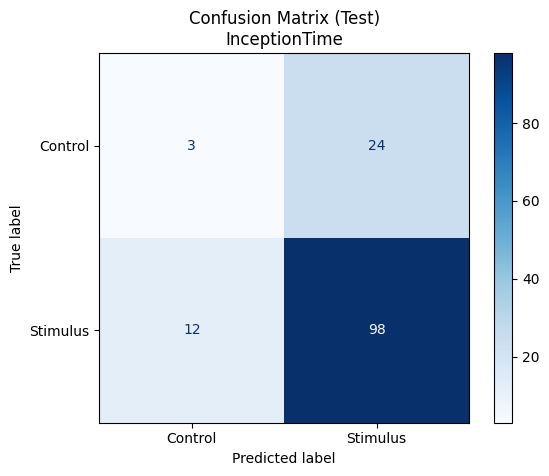

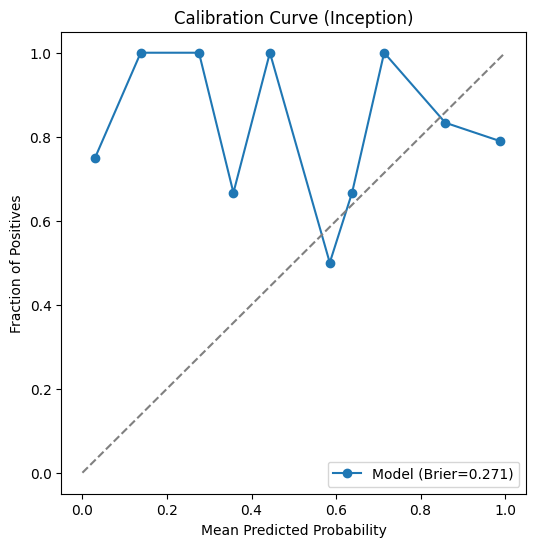


👶 Per-Baby Performance Analysis...

Per-Baby F1 Scores (Test):
------------------------------------------------------------
BabyID: bam1_005   | Age: 5.42  | Sex: F   | F1 Score: 0.7742
BabyID: bam1_026   | Age: 6.54  | Sex: F   | F1 Score: 0.8235
BabyID: bam1_008   | Age: 6.70  | Sex: F   | F1 Score: 0.8387
BabyID: bam1_018   | Age: 4.96  | Sex: M   | F1 Score: 0.8485
BabyID: bam1_024   | Age: 6.41  | Sex: F   | F1 Score: 0.8485
BabyID: bam1_020   | Age: 4.83  | Sex: F   | F1 Score: 0.8571
BabyID: bam1_044   | Age: 6.08  | Sex: M   | F1 Score: 0.9143
------------------------------------------------------------


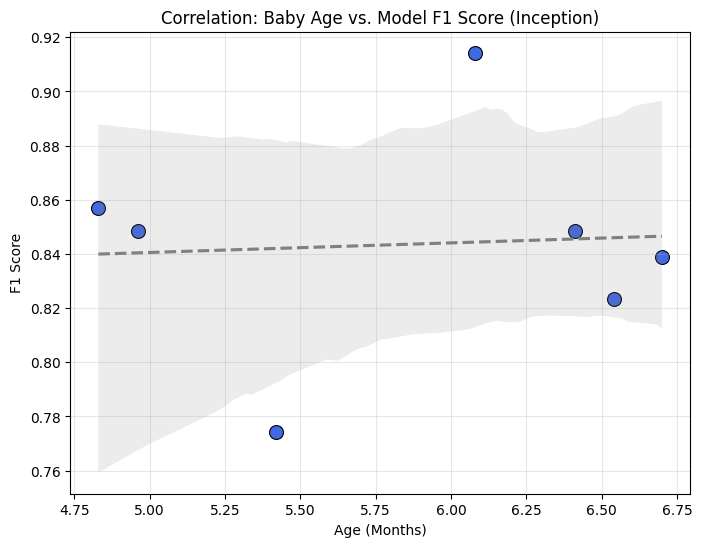


✅ Analysis Complete. Results saved to results_InceptionTime


In [4]:
# %% --- Evaluation ---
print("\n📝 Evaluating on Test Set...")
model.load_state_dict(best_model_state)
model.eval()

test_probs, test_labels = [], []
with torch.no_grad():
    for xb, xm, yb in test_loader:
        xb, xm = xb.to(DEVICE), xm.to(DEVICE)
        logits = model(xb, xm)
        test_probs.extend(torch.sigmoid(logits).cpu().numpy())
        test_labels.extend(yb.numpy())

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)

y_pred_test = (test_probs >= best_thr).astype(int)
bal_test = balanced_accuracy_score(test_labels, y_pred_test)
mcc_test = matthews_corrcoef(test_labels, y_pred_test)
brier_test = brier_score_loss(test_labels, test_probs)

print(f"\nTEST Balanced Accuracy: {bal_test:.4f}")
print(f"TEST MCC: {mcc_test:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, y_pred_test, digits=4))

# Save Text Report
with open(OUT_DIR / "inception_classification_report_test.txt", "w") as f:
    f.write(classification_report(test_labels, y_pred_test, digits=4))

# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred_test)
plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Stimulus"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Test)\nInceptionTime")
plt.savefig(OUT_DIR / "inception_confusion_matrix_test.png")
plt.show()

# Calibration
frac_pos, mean_pred = calibration_curve(test_labels, test_probs, n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(mean_pred, frac_pos, marker='o', label=f'Model (Brier={brier_test:.3f})')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Inception)')
plt.legend()
plt.savefig(OUT_DIR / "inception_calibration_curve_test.png")
plt.show()

# Per-Baby Analysis
print("\n👶 Per-Baby Performance Analysis...")
pt_ids = df_test_meta['pt_id'].unique()
per_baby_details = []
per_baby_f1_list = []

df_test_meta['pred_prob'] = test_probs
df_test_meta['pred_label'] = y_pred_test
df_test_meta['true_label'] = test_labels

for pid in pt_ids:
    sub = df_test_meta[df_test_meta['pt_id'] == pid]
    if len(sub) < 2: continue
    f1 = f1_score(sub['true_label'], sub['pred_label'], zero_division=0)
    age = sub['age'].iloc[0]
    sex_val = sub['sex'].iloc[0]
    sex_str = "F" if str(sex_val) == "0" else "M" if str(sex_val) == "1" else str(sex_val)
    per_baby_details.append((pid, age, sex_str, f1))
    per_baby_f1_list.append(f1)

per_baby_details.sort(key=lambda x: x[3])
print("\nPer-Baby F1 Scores (Test):")
print("-" * 60)
for pid, age, sex, f1 in per_baby_details:
    print(f"BabyID: {pid:<10} | Age: {age:<5.2f} | Sex: {sex:<3} | F1 Score: {f1:.4f}")
print("-" * 60)

# Scatter Plot: Age vs F1
ages = [x[1] for x in per_baby_details]
f1s = [x[3] for x in per_baby_details]
plt.figure(figsize=(8, 6))
sns.scatterplot(x=ages, y=f1s, s=100, color='royalblue', edgecolor='black')
sns.regplot(x=ages, y=f1s, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title("Correlation: Baby Age vs. Model F1 Score (Inception)")
plt.xlabel("Age (Months)")
plt.ylabel("F1 Score")
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR / "inception_age_vs_f1_scatter.png")
plt.show()

print("\n✅ Analysis Complete. Results saved to", OUT_DIR)